# Suppor Vector Regressor - NSAC

In [1]:
# Connect to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Read data from Google Drive.
# Data is already clean.

file_path = "/content/drive/MyDrive/Doutorado CAV 2024/Análises no Colab/JSTARS_153_samples.csv"
data = pd.read_csv(file_path, decimal=',')

# Separate response and predictor variables

X = data.iloc[:, 14:221]  # Spectral bands
y = data['V_hectare']     # Volume to be predicted

In [3]:
X.head()

,Band 1,Band 2,Band 3,Band 4,Band 5,Band 6,Band 7,Band 8,Band 9,Band 10,...,Band 198,Band 199,Band 200,Band 201,Band 202,Band 203,Band 204,Band 205,Band 206,Band 207
0,0.0151,0.0103,0.0087,0.0127,0.0118,0.0105,0.0124,0.0118,0.0132,0.0129,...,0.0274,0.0262,0.0282,0.0244,0.0253,0.0201,0.0208,0.0193,0.0188,0.0105
1,0.0141,0.0079,0.0097,0.0129,0.0105,0.0111,0.0114,0.0122,0.0132,0.0127,...,0.0273,0.0257,0.0246,0.0230,0.0252,0.0205,0.0227,0.0188,0.0203,0.0125
2,0.0102,0.0074,0.0081,0.0094,0.0096,0.0107,0.0109,0.0101,0.0118,0.0127,...,0.0275,0.0256,0.0280,0.0234,0.0224,0.0196,0.0215,0.0175,0.0183,0.0144
3,0.0128,0.0108,0.0105,0.0108,0.0103,0.0122,0.0122,0.0120,0.0126,0.0126,...,0.0276,0.0241,0.0281,0.0243,0.0221,0.0220,0.0204,0.0177,0.0187,0.0138
4,0.0128,0.0106,0.0095,0.0103,0.0095,0.0126,0.0130,0.0110,0.0120,0.0138,...,0.0267,0.0254,0.0251,0.0251,0.0226,0.0192,0.0208,0.0170,0.0187,0.0123


In [4]:
y.head()

,V_hectare
0,359.184
1,377.143
2,343.643
3,320.322
4,380.408


In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Preprocessing (PCA)

In [6]:
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Data preprocessing

# Scale the features
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)

# Note: Scaling 'y' was previously observed to worsen model performance.

# Apply PCA for dimensionality reduction
# PCA was configured to retain 3 components, typically explaining 95% or more of the variance.
pca_basica_svr = PCA(n_components=3, svd_solver='full')
X_train_pca = pca_basica_svr.fit_transform(X_train_scaled)
X_test_pca = pca_basica_svr.transform(X_test_scaled)

# If PCA is not desired, use X_train_scaled and X_test_scaled directly for model training.

print("\n========================================")
print("A. PCA Metrics")
print("========================================")
print(f"  Number of Components: {pca_basica_svr.n_components_}")
print(f"  Explained Variance Ratio per Component: {pca_basica_svr.explained_variance_ratio_}")
print(f"  Cumulative Explained Variance: {pca_basica_svr.explained_variance_ratio_.sum() * 100:.2f}%")
print(f"  Variance Value per Component: {pca_basica_svr.explained_variance_}")


A. PCA Metrics
  Number of Components: 3
  Explained Variance Ratio per Component: [0.5849616  0.26668474 0.06910742]
  Cumulative Explained Variance: 92.08%
  Variance Value per Component: [122.08777067  55.6599698   14.42346028]


In [7]:
# GridSearchCV for SVR hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Hyperparameter Tuning for SVR

# Define the hyperparameter grid for SVR
param_grid_svr = {
    'kernel': ['rbf','linear'],
    'C': [70, 120],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

# Create GridSearchCV object for SVR
grid_search_svr = GridSearchCV(estimator=SVR(),
                                param_grid=param_grid_svr,
                                cv=5,  # 5-fold cross-validation
                                scoring='r2', # Use R2 as the scoring metric
                                n_jobs=-1, # Use all available CPU cores
                                verbose=1) # Display progress

# Fit the GridSearchCV to the data
grid_search_svr.fit(X_train_pca, y_train)

# Print the best parameters and score
print("Best parameters found for SVR:")
print(grid_search_svr.best_params_)
print(f"Best R2 score found for SVR: {grid_search_svr.best_score_}")

# Store the best estimator found by GridSearchCV
best_svr_model = grid_search_svr.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found for SVR:
{'C': 120, 'gamma': 'scale', 'kernel': 'rbf'}
Best R2 score found for SVR: 0.6222571467607069


# Training and graphics

SVR Training Time: 0.0043 seconds
SVR Prediction Time: 0.0011 seconds

R² on Test Data (original scale): 0.617
RMSE on Test (original scale): 72.59
MSE on Test (original scale): 5269.44
MAE on Test (original scale): 57.57
RRMSE on Test (original scale): 17.13%

SVR Training Metrics:

R² of TRAINING (original scale): 0.736
RMSE (SVR Training - original scale): 56.91
MSE (SVR Training - original scale): 3238.67
MAE (SVR Training - original scale): 40.82
RRMSE (SVR Training - original scale): 13.31%

Difference in R² (Train - Test): 0.120


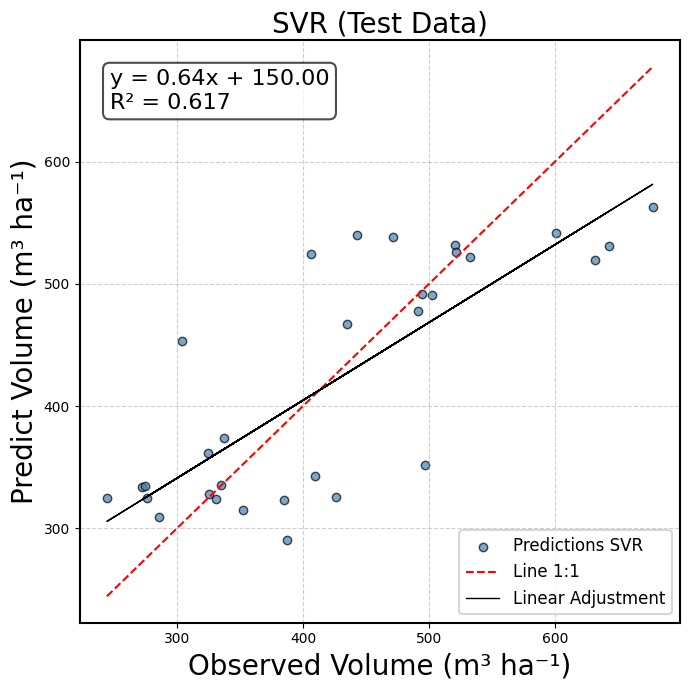

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import time

# SVR Model Training

start_training_time = time.perf_counter()
best_svr_model.fit(X_train_pca, y_train)
training_time = time.perf_counter() - start_training_time
print(f"SVR Training Time: {training_time:.4f} seconds")

# Make predictions and evaluate performance on the TEST set

# Predictions on the test set (in original y scale)
start_prediction_time = time.perf_counter()
y_pred_test = best_svr_model.predict(X_test_pca)
prediction_time = time.perf_counter() - start_prediction_time
print(f"SVR Prediction Time: {prediction_time:.4f} seconds")

y_test_original = y_test.values

# Calculate metrics for the TEST set (in original scale)
r2_test = r2_score(y_test_original, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred_test))
mse_test = mean_squared_error(y_test_original, y_pred_test)
mae_test = mean_absolute_error(y_test_original, y_pred_test)
rrmse_test = (rmse_test / np.mean(y_test_original)) * 100

# Print test set results
print(f"\nR² on Test Data (original scale): {r2_test:.3f}")
print(f"RMSE on Test (original scale): {rmse_test:.2f}")
print(f"MSE on Test (original scale): {mse_test:.2f}")
print(f"MAE on Test (original scale): {mae_test:.2f}")
print(f"RRMSE on Test (original scale): {rrmse_test:.2f}%")


# Evaluate Training Data (in original scale)
print("\nSVR Training Metrics:")

# Predictions on the training set (in original y scale)
y_pred_train = best_svr_model.predict(X_train_pca)

y_train_original = y_train.values

r2_train = r2_score(y_train_original, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_original, y_pred_train))
mse_train = mean_squared_error(y_train_original, y_pred_train)
mae_train = mean_absolute_error(y_train_original, y_pred_train)
rrmse_train = (rmse_train / np.mean(y_train_original)) * 100

print(f"\nR² of TRAINING (original scale): {r2_train:.3f}")
print(f"RMSE (SVR Training - original scale): {rmse_train:.2f}")
print(f"MSE (SVR Training - original scale): {mse_train:.2f}")
print(f"MAE (SVR Training - original scale): {mae_train:.2f}")
print(f"RRMSE (SVR Training - original scale): {rrmse_train:.2f}%")
print(f"\nDifference in R² (Train - Test): {(r2_train - r2_test):.3f}")


# Observed vs. Predicted Plot

plt.figure(figsize=(7, 7))
# Scatter plot of predictions vs. observed values
plt.scatter(y_test_original, y_pred_test, color='steelblue', edgecolor='black', alpha=0.7, label='Predictions SVR')

# 1:1 line (perfect prediction)
min_val = min(y_test_original.min(), y_pred_test.min())
max_val = max(y_test_original.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Line 1:1', linewidth=1.5)

# Fit a simple linear regression line for visualization
reg_line = LinearRegression()
reg_line.fit(y_test_original.reshape(-1, 1), y_pred_test.reshape(-1, 1))
slope = reg_line.coef_[0][0]
intercept = reg_line.intercept_[0]
y_fit = reg_line.predict(y_test_original.reshape(-1, 1))

# Plot the fitted line
plt.plot(y_test_original, y_fit, color='black', linewidth=1, label='Linear Adjustment')

# Display equation and R² (using the R² from the test set in original scale)
eq_text = f"y = {slope:.2f}x + {intercept:.2f}\nR² = {r2_test:.3f}"
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Plot configurations
plt.xlabel("Observed Volume (m³ ha⁻¹)").set_fontsize(20)
plt.ylabel("Predict Volume (m³ ha⁻¹)").set_fontsize(20)
plt.title("SVR (Test Data)").set_fontsize(20)
legend = plt.legend(frameon=True, fontsize=12)
legend.get_frame().set_linewidth(1.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Increase border thickness
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
# Save plot at 600 dpi
plt.savefig('svr_observed_vs_predicted.png', dpi=600)
plt.show()

# PCA Analysis

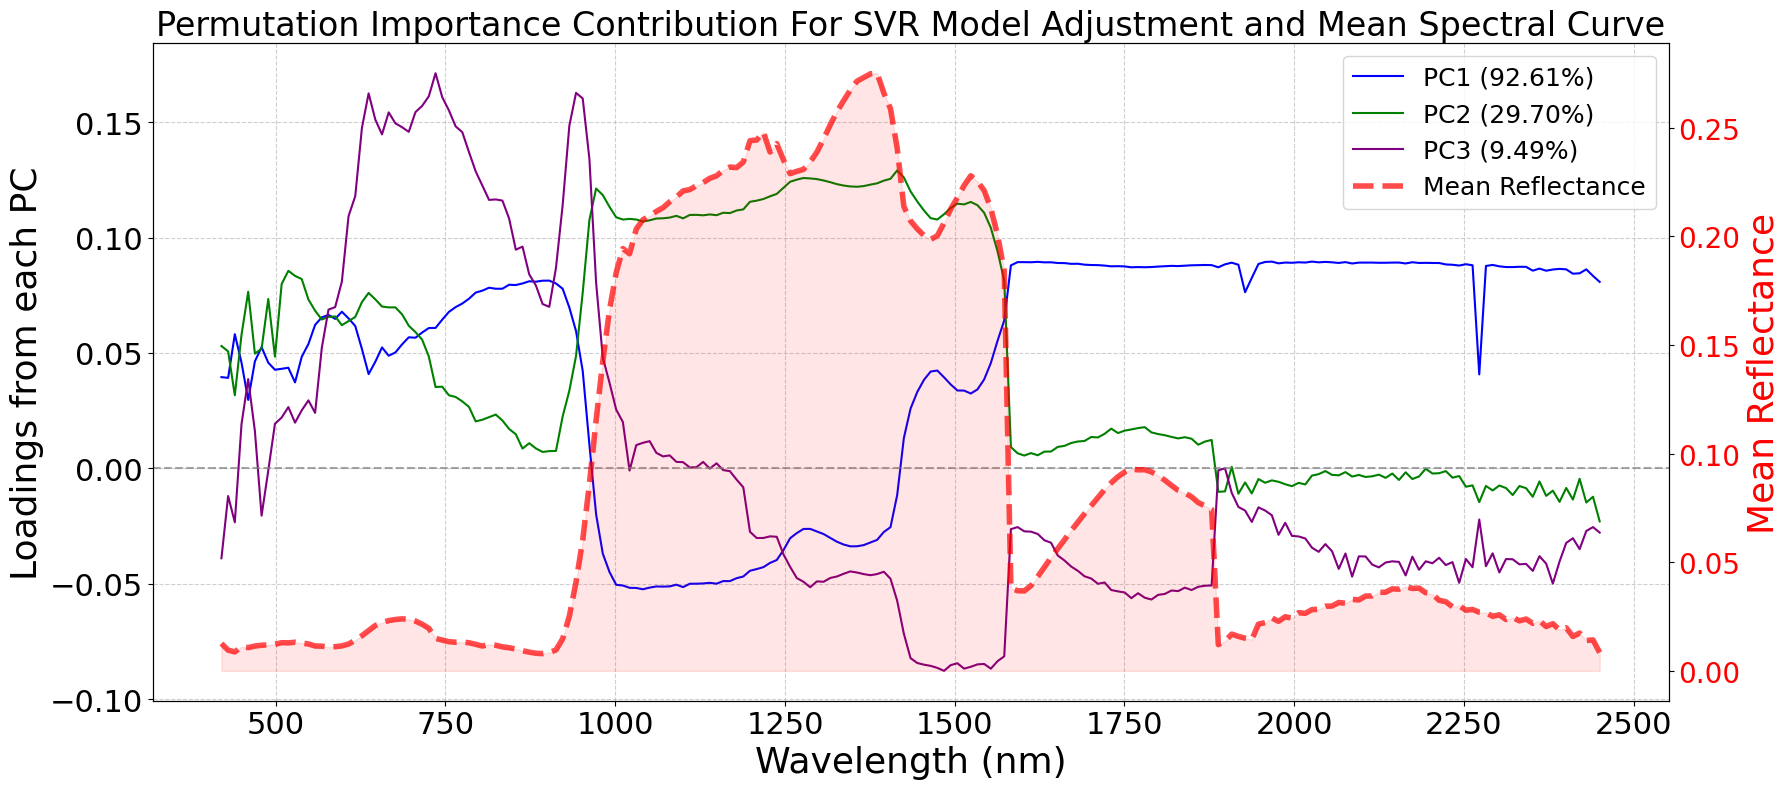

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from sklearn.inspection import permutation_importance

# Define EnMAP wavelengths (assuming 207 bands linearly distributed between 420nm and 2450nm)
enmap_wavelengths = np.linspace(420, 2450, X.shape[1])

# Calculate the mean spectral curve (mean reflectance for each band)
mean_spectral_curve = X.mean(axis=0)

# Re-scale and PCA transform the full X data for permutation importance calculation
X_scaled_for_svr_importance = X_scaler.transform(X)
X_pca_for_svr_importance = pca_basica_svr.transform(X_scaled_for_svr_importance)

# Calculate permutation importance for SVR's PCA components
perm_importance_pca_components_svr = permutation_importance(
    best_svr_model, X_pca_for_svr_importance, y, n_repeats=10, random_state=42, n_jobs=-1
)
pc_importances_svr = perm_importance_pca_components_svr.importances_mean

# Determine the top 3 PCs based on their permutation importance (consistent with n_components=3 for PCA)
top_k = 3
top_pcs_svr = np.argsort(pc_importances_svr)[::-1][:top_k]

loadings_svr = pca_basica_svr.components_

# Create the plot with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(18, 8))

# Define colors for the PCA loadings
colors = ['blue', 'green', 'purple']

# Plot PCA Loadings on ax1 (left y-axis)
for i, pc_idx in enumerate(top_pcs_svr):
    ax1.plot(
        enmap_wavelengths,
        loadings_svr[pc_idx],
        label=f'PC{pc_idx+1} ({pc_importances_svr[pc_idx]*100:.2f}%)',
        color=colors[i],
        linewidth=1.5
    )

ax1.axhline(0, linestyle='--', color='gray', alpha=0.7)
ax1.set_xlabel('Wavelength (nm)', fontsize=26)
ax1.set_ylabel('Loadings from each PC', fontsize=26, color='black')
ax1.tick_params(axis='y', labelcolor='black', labelsize=22)
ax1.tick_params(axis='x', labelsize=22)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for the mean spectral curve
ax2 = ax1.twinx()
ax2.plot(enmap_wavelengths, mean_spectral_curve, label='Mean Reflectance', color='red', linestyle='--', linewidth=4, alpha=0.7)
ax2.fill_between(enmap_wavelengths, mean_spectral_curve, color='red', alpha=0.1)
ax2.set_ylabel('Mean Reflectance', fontsize=26, color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=20)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, fontsize=18)

ax1.set_title('Permutation Importance Contribution For SVR Model Adjustment and Mean Spectral Curve', fontsize=24)
plt.tight_layout()
# To save the plot at 600 dpi, uncomment the line below:
#plt.savefig('svr_pca_loadings.png', dpi=600)
plt.show()

# Make plot border lines darker
ax1.spines['left'].set_edgecolor('black')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_edgecolor('black')
ax1.spines['bottom'].set_linewidth(1.5)
ax2.spines['right'].set_edgecolor('black')
ax2.spines['right'].set_linewidth(1.5)
ax2.spines['top'].set_edgecolor('black')

# Cross-Validation

Average fit time (training): 0.0241 seconds
Average score time (prediction): 0.0076 seconds

R² (CV for SVR with Pipeline - cross_val_predict): 0.626
RMSE (CV for SVR with Pipeline - cross_val_predict): 67.78
MSE (CV for SVR with Pipeline - cross_val_predict): 4593.92
MAE (CV for SVR with Pipeline - cross_val_predict): 55.02
RRMSE (CV for SVR with Pipeline - cross_val_predict): 15.85%

Mean Coefficient of Determination (RepeatedKFold 10-folds, 5 repetitions with Pipeline - cross_val_score):
  Mean R²: 0.5880
  Mean RMSE: 65.8388
  Std (R²):   0.1575
  Std (RMSE): 11.9992
  Range (R²): 0.2179 - 0.8616


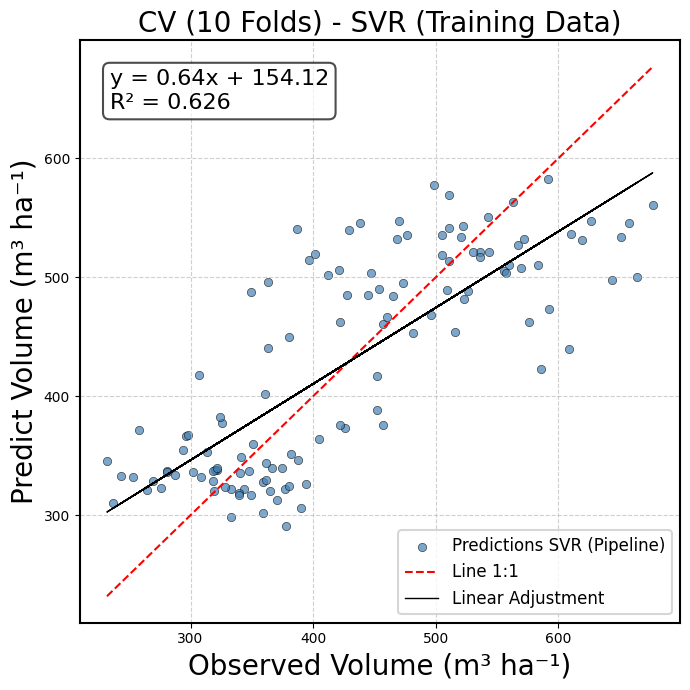

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_predict, KFold, cross_val_score, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure y is in numpy array format (if not already)
y = data['V_hectare'].values

# 1. Create the Pipeline
# The pipeline will handle StandardScaler and PCA fitting within each CV fold to prevent data leakage.
pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3, svd_solver='full')), # PCA will be fitted within each fold
    ('svr', SVR(**best_svr_model.get_params())) # Use fresh instance of SVR with best params
])

# 2. Cross-validation with 10-fold using the Pipeline
# CV strategy for cross_val_predict (partitions)
cv_predict = KFold(n_splits=10, shuffle=True, random_state=42)

# CV strategy for cross_val_score (robust metric estimation)
cv_score = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)

# Pass raw X_train to the pipeline for CV
y_pred_cv_svr_pipeline = cross_val_predict(pipeline_svr, X_train, y_train, cv=cv_predict, n_jobs=-1)

# Get fit and score times
# Using cv_score for cross_validate to get average fit/score times over repetitions
result_tempo_cv_svr = cross_validate(pipeline_svr, X_train, y_train, cv=cv_score, scoring='r2', n_jobs=-1)
print("Average fit time (training): {:.4f} seconds".format(result_tempo_cv_svr['fit_time'].mean()))
print("Average score time (prediction): {:.4f} seconds".format(result_tempo_cv_svr['score_time'].mean()))

# 3. Evaluate cross-validation metrics (cross_val_predict)
r2_cv_svr_pipeline = r2_score(y_train, y_pred_cv_svr_pipeline)
rmse_cv_svr_pipeline = np.sqrt(mean_squared_error(y_train, y_pred_cv_svr_pipeline))
mse_cv_svr_pipeline = mean_squared_error(y_train, y_pred_cv_svr_pipeline)
mae_cv_svr_pipeline = mean_absolute_error(y_train, y_pred_cv_svr_pipeline)
rrmse_cv_svr_pipeline = (rmse_cv_svr_pipeline / np.mean(y_train))*100 # Use y_train mean for RRMSE


print(f"\nR² (CV for SVR with Pipeline - cross_val_predict): {r2_cv_svr_pipeline:.3f}")
print(f"RMSE (CV for SVR with Pipeline - cross_val_predict): {rmse_cv_svr_pipeline:.2f}")
print(f"MSE (CV for SVR with Pipeline - cross_val_predict): {mse_cv_svr_pipeline:.2f}")
print(f"MAE (CV for SVR with Pipeline - cross_val_predict): {mae_cv_svr_pipeline:.2f}")
print(f"RRMSE (CV for SVR with Pipeline - cross_val_predict): {rrmse_cv_svr_pipeline:.2f}%")

# Calculate R² and RMSE of folds for mean and standard deviation (cross_val_score)
# Using cv_score for cross_val_score
cv_scores_r2_svr = cross_val_score(pipeline_svr, X_train, y_train, cv=cv_score, scoring='r2', n_jobs=-1)
cv_scores_rmse_svr = -cross_val_score(pipeline_svr, X_train, y_train, cv=cv_score, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f"\nMean Coefficient of Determination (RepeatedKFold 10-folds, 5 repetitions with Pipeline - cross_val_score):")
print(f"  Mean R²: {cv_scores_r2_svr.mean():.4f}")
print(f"  Mean RMSE: {cv_scores_rmse_svr.mean():.4f}")
print(f"  Std (R²):   {cv_scores_r2_svr.std():.4f}")
print(f"  Std (RMSE): {cv_scores_rmse_svr.std():.4f}")
print(f"  Range (R²): {cv_scores_r2_svr.min():.4f} - {cv_scores_r2_svr.max():.4f}")

# 4. Observed vs. Predicted Plot with Regression Line
slope_svr_cv_pipeline, intercept_svr_cv_pipeline, r_value_svr_cv_pipeline, p_value_svr_cv_pipeline, std_err_svr_cv_pipeline = linregress(y_train, y_pred_cv_svr_pipeline)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_train, y=y_pred_cv_svr_pipeline, color="steelblue", edgecolor='k', alpha=0.7, label='Predictions SVR (Pipeline)')

# 1:1 line (perfect prediction)
min_val_cv = min(y_train.min(), y_pred_cv_svr_pipeline.min()) # Use y_train min/max
max_val_cv = max(y_train.max(), y_pred_cv_svr_pipeline.max()) # Use y_train min/max
plt.plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], 'r--', label='Line 1:1', linewidth=1.5)

# Fitted regression line
plt.plot(y_train, intercept_svr_cv_pipeline + slope_svr_cv_pipeline*y_train, color='black', linewidth=1, label='Linear Adjustment') # Use y_train for plotting line

# Text with equation and R²
eq_text_svr_cv_pipeline = f"y = {slope_svr_cv_pipeline:.2f}x + {intercept_svr_cv_pipeline:.2f}\nR² = {r2_cv_svr_pipeline:.3f}"
plt.text(0.05, 0.95, eq_text_svr_cv_pipeline, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Plot configurations
plt.xlabel("Observed Volume (m³ ha⁻¹)").set_fontsize(20)
plt.ylabel("Predict Volume (m³ ha⁻¹)").set_fontsize(20)
plt.title("CV (10 Folds) - SVR (Training Data)").set_fontsize(20)
legend = plt.legend(frameon=True, fontsize=12)
legend.get_frame().set_linewidth(1.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
# Save plot at 600 dpi
plt.savefig('grafico_cv_svr_pipeline.png', dpi=600)
plt.show()